<sub>Felix Becker, Lars Gabriel, Mario Stanke University of Greifswald, Germany</sub>
# Exercise Set 2 - 1: A simple neural network for bike rentals

We will now create a simple neural network that predicts rental counts based on different attributes as defined in the first exercise (matrix $X$).

We will also learn how to optimize relevant hyperparameters of the model without underestimating the true test error.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchsummary import summary

## Task 1: Preparations

Shuffle with `np.random.shuffle` and split X and y into ``X_train``, ``X_test``, ``y_train`` and ``y_test``.

In [2]:
np.random.seed(0) # so we all get the same pseudorandom results, do not modify or remove this line!

# load X and y
X = np.load("../X.npy")
y = np.load("../y.npy")

m, n = X.shape
print ("number of features: ", n)

number of features:  19


In [3]:
# split into train and test
test_split = 0.1

# shuffle X and y (attention, shuffle them together, i.e. keep the one-one correspondance of rows of X and values in y)
# split X and y by keeping the first (test_split*100)% examples for testing. Use the rest for training.
# Name the splitted values X_train, X_test, y_train and y_test.
perm = np.arange(m)
np.random.shuffle(perm) # shuffle all data examples, why is this important?

# YOUR CODE STARTS
# replace these lines
X_train, X_test = X, X
y_train, y_test = y, y

# YOUR CODE ENDS

## Task 2: Model search

0. Run all cells until Task 3 as they are now, i.e. without adding your own code yet. This trains a linear regression (i.e. a neural network without hidden layers) as a baseline model.
1. Then return to the cell below and create a small neural network with hidden layers of various sizes and an activation function of your choice.
2. After training, take note of *validation* error, come back here, change some hyperparameters and train again. Also adapt the L2 value (nonnegative) which serves as a *regularizer*. Iterate as much as you like, but do not base decisions on the *test* error (ignore it, for now). 
3. Report (as a group) the final *test* error of the best model and its configuration. Who wins? What is the improvement with respect to the baseline model (linear regression)?

In [4]:
torch.manual_seed(0)  # so we all get the same pseudorandom results, do not modify or remove

l2 = 0.01  # strength of L2 regularization; pass as weight_decay to the optimizer

def make_model(input_dim):
    layers = []
    in_features = input_dim
    # YOUR CODE STARTS
    # Add Dense neural network layers, choose number of layers, number of 
    # hidden neurons, activation functions at will
    # layers.append(...)
    # YOUR CODE ENDS

    layers.append(nn.Linear(in_features, 1))  # last layer maps to output size 1, no activation
    model = nn.Sequential(*layers)
    return model

model = make_model(n) # m is the input dimension

In addition to our loss (MSE) we use the **Root Mean Squared Error** as a metric.

$RMSE(\theta) = \sqrt(MSE(\theta))$

It can be interpreted as an average distance of our prediction to the true value.

A **metric** is (in constrast to a **loss**) not used for model optimization but for evaluation.

In [5]:
criterion = nn.MSELoss()

def fit_model(model, X_train, y_train, epochs=200, learning_rate=0.01, batch_size=64, L2=0.01):
    # Convert input data to torch tensors if necessary
    X_train = torch.from_numpy(X_train).float()
    y_train = torch.from_numpy(y_train).float().view(-1, 1)
    
    # Create dataset and split original training data into training and validation sets (15% validation)
    dataset = TensorDataset(X_train, y_train)
    val_size = int(len(dataset) * 0.15)
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    # Define loss function and optimizer (using weight_decay as L2 regularizer)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=L2)
    
    # Initialize history dict to store metrics over epochs
    history = {'loss': [], 'val_loss': [], 'rmse': [], 'val_rmse': []}
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * X_batch.size(0)
        avg_train_loss = running_train_loss / train_size
        
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_val_loss += loss.item() * X_batch.size(0)
        avg_val_loss = running_val_loss / val_size
        
        # Compute RMSE from MSE for both training and validation
        rmse = np.sqrt(avg_train_loss)
        val_rmse = np.sqrt(avg_val_loss)
        
        history['loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['rmse'].append(rmse)
        history['val_rmse'].append(val_rmse)
    
    return history

In [6]:
# takes ~1min
# a larger batch size can speed this up, however it can negatively affect the outcome
# since fewer training steps are made
# the same is true for smaller numbers of epochs
batch_size = 64
L2 = 0.01
history = fit_model(model, X_train, y_train, batch_size=batch_size, L2=L2)

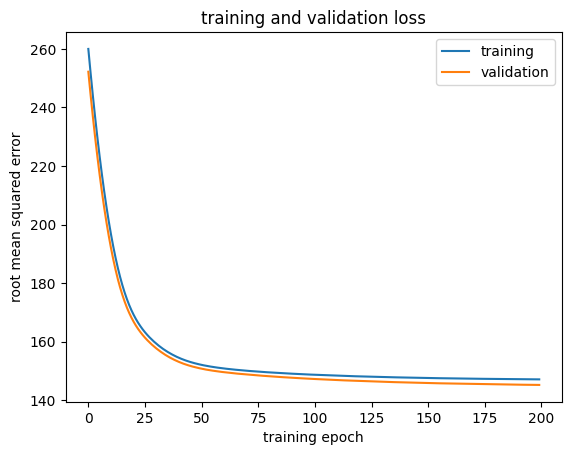

In [7]:
fig, ax= plt.subplots(1,1)
def plot_hist(history, ax, title, ylim=None):
    ax.plot(history["rmse"], label="training") 
    ax.plot(history["val_rmse"], label="validation") 
    ax.set_title(title)
    ax.set_xlabel("training epoch")
    ax.set_ylabel("root mean squared error")
    handles, labels = ax.get_legend_handles_labels()
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(handles, labels)
plot_hist(history, ax, "training and validation loss")

In [8]:
# for simplicity we take the last validation loss only
print("val mse=", history["val_rmse"][-1])

val mse= 145.17447376844896


In [9]:
def evaluate(model, y):
    # compute test error
    model.eval()
    with torch.no_grad():
        outputs = model(torch.from_numpy(X_test).float())
        test_loss = criterion(outputs, torch.from_numpy(y).view(-1, 1).float())  # using the 
    return np.sqrt(test_loss.item()), outputs.numpy().flatten()
rmse, outputs = evaluate(model, y_test)
print("test mse, rmse=", rmse)

test mse, rmse= 146.7762300876746


In [10]:
print("predictions =\t", outputs.astype(np.int32))
print("truth =\t\t", y_test)

predictions =	 [-35 -33 -28 ... 239 247 236]
truth =		 [ 16  40  32 ... 168 129  88]


Iterate at least until you have a lower validation RMSE than with the linear regression baseline.

## Task 3: Transfer learning and Fine-Tuning

We now have a well working neural network architecture and a trained ``model`` at hand. Naturally, as a black box, we can hardly tell anything about the inner workings of the neural network, i.e. we see that a prediction is good, but can't tell why.

However, we expect the inner layers of the neural network to learn *something* about the semantics of the problem space at hand.

To see this, assume we now have a different training target that is related to the original one. The dataset contains a "registered" column that counts only those rentals, with a registration (club membership). "registered" is similar to count, but not the same because it misses casual rentals. Maybe we can expect casual rentals to be higher in summer and spring and expect registered members to use the service more regularily over the year. In machine learning terms predicting 'registered' is a different but related *task*.

*Question: Can we use the hidden features of the already trained model for "count" to train a model for "registered"?*

To answer this, you will train two models in the following: 
1. ``model1`` is identical to the original model except the last layer (Dense(1))
2. ``model2`` is completely new

To achieve this, use the trained ``model`` from previous cells and access its layer list with ``model.layers``. Reuse these layers for the new model (``.add``) and remember to leave out the last layer. Replace it with a new one and also apply L2 regularization to it.

Use ``fit_model`` to train both models on ``y_registered_train`` and try fewer epochs (e.g. 100) for model1 as it already has trained hidden features. This is called *fine-tuning* as we are using already trained parameters (as opposed to randomly initialized ones in `model2`) and continue their training, albeit for another task.

Name the two return values of ``fit_model`` depending on whether fine-tuning used or not `history1` and `history2`, respectively.

How does the loss curve change?

In [11]:
y_registered = pd.read_csv("../bikes-summerdays-full.csv", sep = ";")["registered"].to_numpy()
k = int(m*test_split)
y_registered_train = y_registered[perm[k:]]
y_registered_test = y_registered[perm[:k]]

In [12]:
# YOUR CODE STARTS
# Construct model1 as described above.
# Reuse all layers except the final one and append a new output layer.
# list(mode.children()) gives you all layers of 'model'
layers = [nn.Linear(n, 32), nn.ReLU()] # replace this

# Create a new final layer; you may choose to adjust its learning rate or regularization.
pass  # replace this

# YOUR CODE ENDS
model1 = nn.Sequential(*layers)

model2 = make_model(n) # learning again from scratch

In [ ]:
# take note that all models have the same architecture and number of parameters
for name, mdl in zip(["model", "model1, transfer learning", "model2"], [model, model1, model2]):
    print (name)
    summary(mdl, input_size=(batch_size, n), device="cpu")

In [ ]:
fig, axes = plt.subplots(1,2)
plot_hist(history1, axes[0], "model1", ylim=(50,150))
plot_hist(history2, axes[1], "model2", ylim=(50,150))

In [ ]:

rmse1, _ = evaluate(model1, y_registered_test) 
rmse2, _ = evaluate(model2, y_registered_test) 

print("test mse 1=", rmse1)
print("test mse 2=", rmse2)

$\implies$ model 1 should achieve similar test errors but training converges much faster

If `model1` performs worse than `model2`, try to transfer fewer layers. If your model architecture is more deep than broad, this might help.
Try to make the cut at a layer with many neurons. If your last hidden layer before the output layer has only 2 neurons, this might be a bottleneck that is too much tuned to the first task and not suitable for transfer learning. Also try to leave out the L2 regularizer on the new layer of `model1` as we do not need to regularize on an already pre-trained model as much.

### Improve the model search 

From here, if you want to practice off-course more or want to apply neural networks to your own data, you should consider averaging the test error over many different training-validation-test splits of the data. This is called **cross-validation** and it will trade experiment time for decreased randomness in the reported result. 